In [ ]:
from google.colab import files
files.upload()  # Upload 'kaggle.json' here

# Install Kaggle API
!pip install kaggle

# Set up Kaggle API credentials
import os
os.environ['KAGGLE_CONFIG_DIR'] = '/content'

# Download dataset from Kaggle
!kaggle datasets download -d paultimothymooney/chest-xray-pneumonia

# Unzip the dataset
!unzip -q '/content/chest-xray-pneumonia.zip' -d '/content'


Saving kaggle.json to kaggle.json
Dataset URL: https://www.kaggle.com/datasets/paultimothymooney/chest-xray-pneumonia
License(s): other
100% 2.29G/2.29G [01:18<00:00, 32.2MB/s]
100% 2.29G/2.29G [01:18<00:00, 31.3MB/s]


Found 5216 images belonging to 2 classes.
Found 16 images belonging to 2 classes.
Found 624 images belonging to 2 classes.
94765736/94765736 ━━━━━━━━━━━━━━━━━━━━ 3s 0us/step
Epoch 1/30


/usr/local/lib/python3.10/dist-packages/keras/src/trainers/data_adapters/py_dataset_adapter.py:121: UserWarning: Your `PyDataset` class should call `super().__init__(**kwargs)` in its constructor. `**kwargs` can include `workers`, `use_multiprocessing`, `max_queue_size`. Do not pass these arguments to `fit()`, as they will be ignored.
  self._warn_if_super_not_called()


163/163 ━━━━━━━━━━━━━━━━━━━━ 177s 678ms/step - accuracy: 0.9013 - loss: 1.1020 - val_accuracy: 0.5000 - val_loss: 4.1734 - learning_rate: 1.0000e-04
Epoch 2/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 164s 644ms/step - accuracy: 0.9621 - loss: 0.8258 - val_accuracy: 0.5000 - val_loss: 2.3328 - learning_rate: 1.0000e-04
Epoch 3/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 110s 644ms/step - accuracy: 0.9653 - loss: 0.6914 - val_accuracy: 0.5000 - val_loss: 2.5504 - learning_rate: 1.0000e-04
Epoch 4/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 644ms/step - accuracy: 0.9736 - loss: 0.5905 - val_accuracy: 0.5000 - val_loss: 4.1247 - learning_rate: 1.0000e-04
Epoch 5/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 143s 645ms/step - accuracy: 0.9849 - loss: 0.5032 - val_accuracy: 0.5000 - val_loss: 8.5415 - learning_rate: 1.0000e-04
Epoch 6/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 141s 645ms/step - accuracy: 0.9863 - loss: 0.4372 - val_accuracy: 0.5000 - val_loss: 4.1691 - learning_rate: 2.0000e-05
Epoch 7/30
163/163 ━━━━━━━━━━━━━━━━━━━━ 109s 647ms/

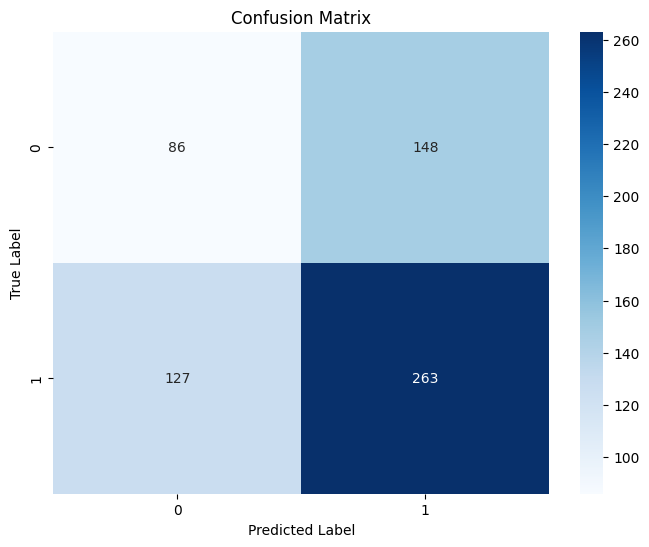

In [ ]:
import os
import numpy as np
import matplotlib.pyplot as plt
import tensorflow as tf
from tensorflow.keras import layers, models, regularizers
from tensorflow.keras.preprocessing.image import ImageDataGenerator
from tensorflow.keras.callbacks import EarlyStopping, ReduceLROnPlateau

# Define paths
dataset_path = '/content/chest_xray'  # Update this path based on the extracted dataset
train_dir = os.path.join(dataset_path, 'train')
val_dir = os.path.join(dataset_path, 'val')
test_dir = os.path.join(dataset_path, 'test')
image_size = (224, 224)  # For example, 224x224 for VGG16

# Data Augmentation
train_datagen = ImageDataGenerator(
    rescale=1./255,
    rotation_range=20,
    width_shift_range=0.2,
    height_shift_range=0.2,
    shear_range=0.2,
    zoom_range=0.2,
    horizontal_flip=True,
    fill_mode='nearest'
)

val_test_datagen = ImageDataGenerator(rescale=1./255)

# Load Data
train_generator = train_datagen.flow_from_directory(
    train_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

val_generator = val_test_datagen.flow_from_directory(
    val_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

test_generator = val_test_datagen.flow_from_directory(
    test_dir,
    target_size=(224, 224),
    batch_size=32,
    class_mode='categorical'
)

# Model Architecture with Adjustments
def create_model(input_shape, num_classes):
    base_model = tf.keras.applications.ResNet50(weights='imagenet', include_top=False, input_shape=input_shape)
    model = models.Sequential()
    model.add(base_model)
    model.add(layers.GlobalAveragePooling2D())
    model.add(layers.Dense(256, activation='relu', kernel_regularizer=regularizers.l2(0.002)))  # Increased L2 regularization
    model.add(layers.Dropout(0.6))  # Increased Dropout
    model.add(layers.Dense(num_classes, activation='softmax'))
    return model

# Create and Compile Model
input_shape = (224, 224, 3)
num_classes = 2  # Pneumonia/Normal
model = create_model(input_shape, num_classes)

model.compile(optimizer=tf.keras.optimizers.Adam(learning_rate=1e-4),  # Increased learning rate
              loss='categorical_crossentropy',
              metrics=['accuracy'])

# Callbacks
early_stopping = EarlyStopping(monitor='val_loss', patience=5, restore_best_weights=True)
reduce_lr = ReduceLROnPlateau(monitor='val_loss', factor=0.2, patience=3, min_lr=1e-6)

# Train the Model
history = model.fit(
    train_generator,
    epochs=30,
    validation_data=val_generator,
    callbacks=[early_stopping, reduce_lr]
)

# Evaluate on Test Data
test_loss, test_accuracy = model.evaluate(test_generator)
print(f'Test Accuracy: {test_accuracy:.4f}')
print(f'Test Loss: {test_loss:.4f}')

# Plotting the Confusion Matrix
from sklearn.metrics import confusion_matrix
import seaborn as sns

# Get true labels and predictions
Y_pred = model.predict(test_generator)
y_pred = np.argmax(Y_pred, axis=1)
y_true = test_generator.classes

# Create confusion matrix
cm = confusion_matrix(y_true, y_pred)

# Plot confusion matrix
plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt="d", cmap='Blues')
plt.title('Confusion Matrix')
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.show()


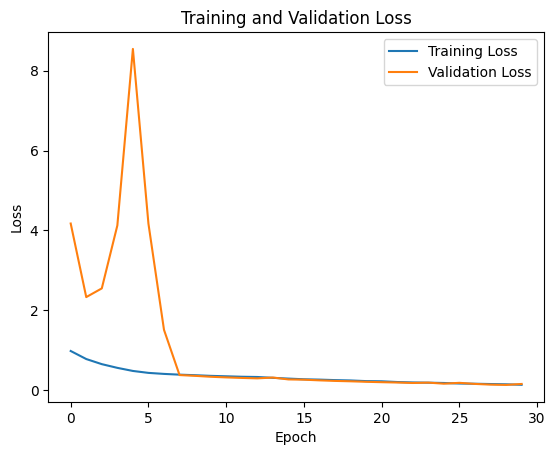

In [ ]:
import matplotlib.pyplot as plt

plt.plot(history.history['loss'], label='Training Loss')
plt.plot(history.history['val_loss'], label='Validation Loss')
plt.title('Training and Validation Loss')
plt.xlabel('Epoch')
plt.ylabel('Loss')
plt.legend()
plt.show()


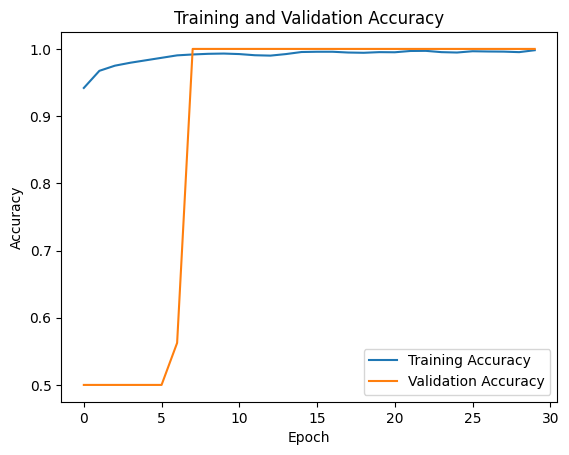

In [ ]:
plt.plot(history.history['accuracy'], label='Training Accuracy')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy')
plt.title('Training and Validation Accuracy')
plt.xlabel('Epoch')
plt.ylabel('Accuracy')
plt.legend()
plt.show()


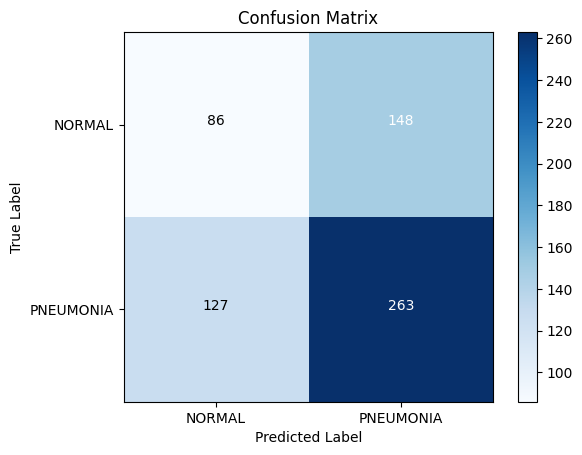

In [ ]:
import matplotlib.pyplot as plt

plt.imshow(cm, interpolation='nearest', cmap=plt.cm.Blues)
plt.colorbar()
class_names = ['NORMAL', 'PNEUMONIA']
# Add labels and title
plt.xticks(np.arange(len(class_names)), class_names)
plt.yticks(np.arange(len(class_names)), class_names)
plt.xlabel('Predicted Label')
plt.ylabel('True Label')
plt.title('Confusion Matrix')

# Add numbers to the matrix cells
thresh = cm.max() / 2.
for i in range(cm.shape[0]):
    for j in range(cm.shape[1]):
        plt.text(j, i, format(cm[i, j], 'd'),
                 horizontalalignment="center",
                 color="white" if cm[i, j] > thresh else "black")

plt.show()


1/1 ━━━━━━━━━━━━━━━━━━━━ 0s 32ms/step


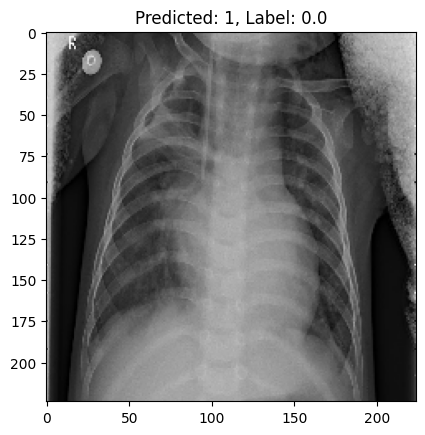

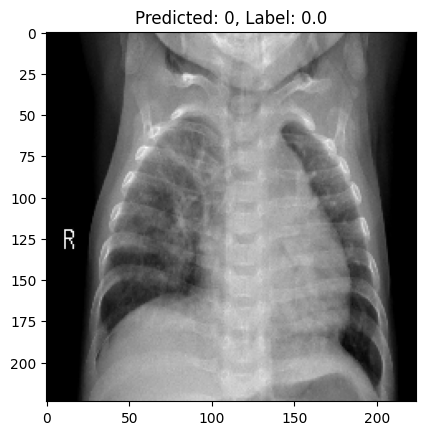

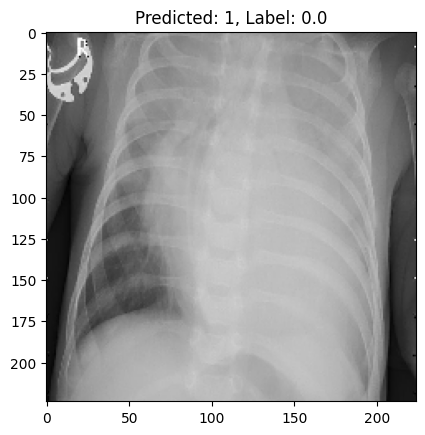

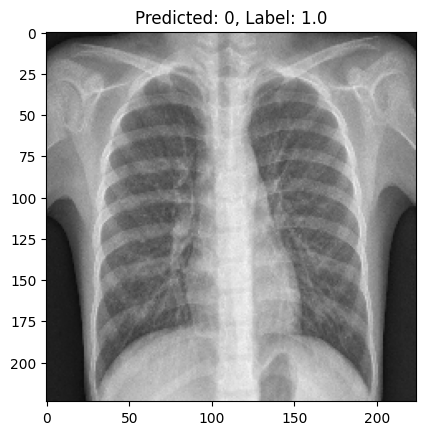

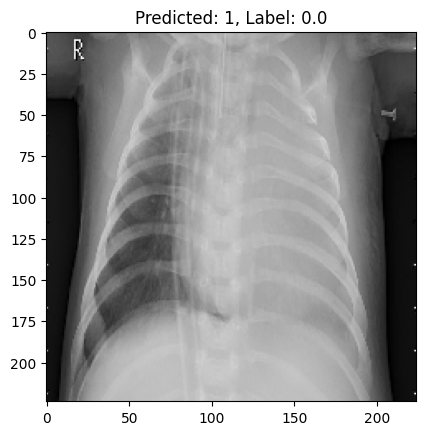

In [ ]:
# Assuming test_generator provides access to images and labels
images, labels = next(test_generator)
predictions = model.predict(images)
predicted_classes = np.argmax(predictions, axis=1)

for i in range(5):  # Show predictions for the first 5 images
    plt.imshow(images[i])
    plt.title(f'Predicted: {predicted_classes[i]}, Label: {labels[i][0]}')
    plt.show()
